# NeuralGCM: daily 10-day rollouts at 6 h (Rackow-style, full-year)

For each climate-state year, run a **10-day forecast initialized every day**, output every **6 h**
(→ 40 forecast frames per init: leads 6 h … 240 h), with the **2.8° deterministic** NeuralGCM and
prescribed time-varying SST. For each init we score the global-mean near-surface (1000 hPa)
temperature against ERA5 and store the per-lead RMSE/bias + predicted global-mean series. Similar to Rackow et al. (2024) Fig. 1 protocol (they average over all ~365 daily forecasts per year).

> **Years:** `1955` (pre-industrial proxy) and `2023` (present-day) — the Rackow et al. climate
> states. Override with `RACKOW_YEARS=...` (e.g. add a future year).

> **Scale / where to run:** 365 inits × 2 years = **730 rollouts** . The loop **writes per-init and is resumable**: re-running skips
> init days already present in the per-year CSV. Use `RACKOW_MAX_INITS` / `RACKOW_INIT_STRIDE_DAYS`
> to test on a subset first. Outputs go to `neural_gcm/results_daily/`.

## 0. Imports and environment

In [2]:
import os

# Disable JAX's 75% pre-grab. IMPORTANT: keep the default (BFC) allocator here, NOT "platform" —
# over a long loop of forecasts the platform allocator churns the ~16.7 GiB working set and can
# hard-kill the kernel on a tight card. BFC pools/reuses memory across inits.
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "default")

import pickle
from pathlib import Path

import gcsfs
import jax
import numpy as np
import pandas as pd
import xarray
import matplotlib.pyplot as plt

from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils
import neuralgcm

print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


## 1. Load the pretrained checkpoint

`v1/deterministic_2_8_deg.pkl` — the 2.8° deterministic model (same as the GraphCast-comparison run).

In [3]:
model_name = "v1/deterministic_2_8_deg.pkl"

gcs = gcsfs.GCSFileSystem(token="anon")
with gcs.open(f"gs://neuralgcm/models/{model_name}", "rb") as f:
    ckpt = pickle.load(f)

model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)
print("input variables  :", model.input_variables)
print("forcing variables:", model.forcing_variables)

input variables  : ['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content']
forcing variables: ['sea_ice_cover', 'sea_surface_temperature']


## 2. Configuration

Each init is a **10-day** rollout at **6 h** output (40 forecast frames + the lead-0 analysis frame).
`YEARS` are the climate-state years; inits are taken every `INIT_STRIDE_DAYS` (1 = every day).

Set **`N_INIT_DAYS`** in the cell below to choose how many init days per year: an int (2, 10, 30, …)
for a subset, or `None` for the **full year** (~365). Env overrides for HPC:
- `RACKOW_YEARS=1955,2023`
- `RACKOW_INIT_STRIDE_DAYS=1`   (use e.g. 7 for a weekly subset)
- `RACKOW_MAX_INITS=2`          (overrides `N_INIT_DAYS`; empty = use `N_INIT_DAYS`)

In [4]:
YEARS = [y.strip() for y in os.environ.get("RACKOW_YEARS", "1955,2023").split(",") if y.strip()]

ROLLOUT_DAYS = int(os.environ.get("RACKOW_ROLLOUT_DAYS", "10")) # 10-day rollout
OUT_H = int(os.environ.get("RACKOW_OUT_H", "6"))          # 6 h output -> 40 frames over 10 days
SST_STRIDE_H = 24                                          # daily prescribed SST (nearest-in-time)
# How many init days to run PER YEAR (each init = its own 10-day/6h rollout):
#   2, 10, 30, ... for a subset   |   None for the FULL YEAR (~365 daily inits).
N_INIT_DAYS = None        # <-- set this (e.g. 2, 10) or None for the whole year
INIT_STRIDE_DAYS = int(os.environ.get("RACKOW_INIT_STRIDE_DAYS", "1"))  # 1 = consecutive days

# env override wins if set, e.g. RACKOW_MAX_INITS=2
_max = os.environ.get("RACKOW_MAX_INITS", "")
MAX_INITS = int(_max) if _max else N_INIT_DAYS

NEAR_SURFACE_LEVEL = 1000  # hPa, t2m proxy (NeuralGCM has no 2 m field)

RESULTS_DIR = Path("results_daily")
RESULTS_DIR.mkdir(exist_ok=True)

N_FRAMES = ROLLOUT_DAYS * 24 // OUT_H + 1
print(f"YEARS={YEARS} | {ROLLOUT_DAYS}-day rollouts @ {OUT_H}h -> {N_FRAMES-1} forecast frames "
      f"(+lead0) | init stride={INIT_STRIDE_DAYS}d | max_inits/yr={MAX_INITS}")

YEARS=['1955', '2023'] | 10-day rollouts @ 6h -> 40 forecast frames (+lead0) | init stride=1d | max_inits/yr=None


## 3. Helper functions

`full_era5` (public ARCO-ERA5 zarr) + a conservative regridder to the model's 2.8° grid are built
once. Helpers load/regrid ERA5, run a prescribed-SST forecast, and score the near-surface temperature.

In [5]:
era5_path = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
full_era5 = xarray.open_zarr(era5_path, chunks=None, storage_options=dict(token="anon"))

era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes["latitude"],
    longitude_nodes=full_era5.sizes["longitude"],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_coords.horizontal, skipna=True
)


def _regrid(ds):
    return xarray_utils.fill_nan_with_nearest(xarray_utils.regrid(ds, regridder))


def _end_str(init_date, days):
    return str(np.datetime64(init_date) + np.timedelta64(days, "D"))


def load_inputs(init_date):
    """Regridded ERA5 atmospheric inputs at the single initial time t0."""
    raw = full_era5[model.input_variables].sel(time=slice(init_date, init_date, 24)).compute()
    return _regrid(raw)


def load_sst_forcing(init_date, days, stride_h):
    """Regridded, time-varying SST / sea-ice forcing trajectory over the rollout."""
    raw = (
        full_era5[model.forcing_variables]
        .pipe(xarray_utils.selective_temporal_shift,
              variables=model.forcing_variables, time_shift="24 hours")
        .sel(time=slice(init_date, _end_str(init_date, days), stride_h))
        .compute()
    )
    return _regrid(raw)


def load_truth_t(init_date, days, out_h):
    """Regridded ERA5 temperature trajectory at out_h cadence (ground truth)."""
    raw = full_era5[["temperature"]].sel(
        time=slice(init_date, _end_str(init_date, days), out_h)
    ).compute()
    return _regrid(raw)


def run_forecast(inputs_ds, forcing_ds, days, out_h):
    """Encode from t0 and unroll with prescribed (time-varying) SST forcing."""
    steps = days * 24 // out_h + 1            # +1 so leads run 0 .. days (start_with_input)
    times = np.arange(steps) * out_h          # lead time in hours
    timedelta = np.timedelta64(1, "h") * out_h

    inputs = model.inputs_from_xarray(inputs_ds.isel(time=0))
    input_forcings = model.forcings_from_xarray(forcing_ds.isel(time=0))
    initial_state = model.encode(inputs, input_forcings, jax.random.key(42))

    all_forcings = model.forcings_from_xarray(forcing_ds)   # time-varying SST, nearest-in-time
    _, predictions = model.unroll(
        initial_state, all_forcings, steps=steps, timedelta=timedelta, start_with_input=True,
    )
    return model.data_to_xarray(predictions, times=times)


def near_surface_t(ds):
    return ds["temperature"].sel(level=NEAR_SURFACE_LEVEL)


def lat_weighted_global_mean(field):
    w = np.cos(np.deg2rad(field.latitude))
    return field.weighted(w).mean(["longitude", "latitude"])


def rollout_metrics(year, init_date):
    """One 10-day/6h forecast: per-lead global-mean pred/truth + RMSE + bias vs ERA5.

    Returns a tidy DataFrame (one row per lead): step 0 is the lead-0 analysis (RMSE 0),
    steps 1..N are the forecast frames [t0+6h, t0+12h, ...]."""
    inputs_ds = load_inputs(init_date)
    forcing_ds = load_sst_forcing(init_date, ROLLOUT_DAYS, SST_STRIDE_H)
    truth_ds = load_truth_t(init_date, ROLLOUT_DAYS, OUT_H)

    pred = run_forecast(inputs_ds, forcing_ds, ROLLOUT_DAYS, OUT_H)
    pred_t = near_surface_t(pred)
    truth_t = near_surface_t(truth_ds).isel(time=slice(0, pred_t.sizes["time"]))
    truth_t = truth_t.assign_coords(time=pred_t["time"])

    diff = pred_t - truth_t
    mse = lat_weighted_global_mean(diff ** 2)
    rmse = np.sqrt(mse)
    bias = lat_weighted_global_mean(diff)
    pgm = lat_weighted_global_mean(pred_t)
    tgm = lat_weighted_global_mean(truth_t)
    lead_h = pred_t["time"].values.astype("float64")
    return pd.DataFrame({
        "year": str(year),
        "init_date": str(np.datetime64(init_date, "D")),
        "step": np.arange(pred_t.sizes["time"], dtype=np.int32),
        "lead_hours": lead_h,
        "lead_day": lead_h / 24.0,
        "mse": np.asarray(mse.values, dtype=np.float64), # TODO: rename mse to t2m_mse_k
        "t2m_pred_gmean_k": np.asarray(pgm.values, dtype=np.float64),
        "t2m_truth_gmean_k": np.asarray(tgm.values, dtype=np.float64),
        "t2m_rmse_k": np.asarray(rmse.values, dtype=np.float64),
        "t2m_mean_bias_k": np.asarray(bias.values, dtype=np.float64),
    })


def init_dates_for_year(year, stride_days, max_inits):
    dates = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq=f"{stride_days}D")
    if max_inits:
        dates = dates[:max_inits]
    return [str(d.date()) for d in dates]

## 4. Run the daily rollouts (resumable)

For each year we loop over the init days and **append each init's per-lead rows to a per-year CSV**.
Re-running skips init days already in the CSV, so the multi-hour job is restartable (and survives a
container restart). Progress is printed every 10 inits.

In [5]:
for year in YEARS:
    csv = RESULTS_DIR / f"daily_rollout_{year}.csv"
    done = set()
    if csv.exists():
        done = set(pd.read_csv(csv, usecols=["init_date"])["init_date"].astype(str).unique())

    dates = init_dates_for_year(year, INIT_STRIDE_DAYS, MAX_INITS)
    todo = [d for d in dates if d not in done]
    print(f"[{year}] {len(dates)} init days total | {len(done)} already done | {len(todo)} to run "
          f"-> {csv}")

    for i, d in enumerate(todo):
        df = rollout_metrics(year, d)
        df.to_csv(csv, mode="a", header=not csv.exists(), index=False)
        if i % 10 == 0 or i == len(todo) - 1:
            print(f"  [{year}] {i+1}/{len(todo)} init {d}: "
                  f"day-10 RMSE={df['t2m_rmse_k'].iloc[-1]:.3f} K "
                  f"bias={df['t2m_mean_bias_k'].iloc[-1]:+.3f} K")
    print(f"[{year}] done.")

[1955] 2 init days total | 0 already done | 2 to run -> results_daily/daily_rollout_1955.csv


W0602 20:02:33.760034   72081 hlo_rematerialization.cc:3233] Can't reduce memory use below 14.80GiB (15893369244 bytes) by rematerialization; only reduced to 16.69GiB (17922342944 bytes), down from 16.69GiB (17922342944 bytes) originally
W0602 20:02:43.880835   72081 bfc_allocator.cc:514] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.63GiB (rounded to 17855234560)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0602 20:02:43.881107   72081 bfc_allocator.cc:525] _________________________________________________*******_________________*********xxxx*****xx*******


  [1955] 1/2 init 1955-01-01: day-10 RMSE=2.886 K bias=+0.160 K
  [1955] 2/2 init 1955-01-02: day-10 RMSE=3.401 K bias=+0.223 K
[1955] done.
[2023] 2 init days total | 0 already done | 2 to run -> results_daily/daily_rollout_2023.csv
  [2023] 1/2 init 2023-01-01: day-10 RMSE=3.481 K bias=-0.024 K
  [2023] 2/2 init 2023-01-02: day-10 RMSE=2.754 K bias=-0.191 K
[2023] done.


## 5. Year-mean skill (average over all inits)

Like the paper's Fig. 1: the per-lead RMSE/bias averaged over all daily forecasts in the year.

In [6]:
# TODO: rename mse to t2m_mse_k
yearmean = {}
for year in YEARS:
    csv = RESULTS_DIR / f"daily_rollout_{year}.csv"
    if not csv.exists():
        continue
    df = pd.read_csv(csv)
    agg = (df.groupby("step", as_index=False)
             .agg(lead_hours=("lead_hours", "first"),
                  lead_day=("lead_day", "first"),
                  mse=("mse", "mean"),
                  t2m_mean_bias_k=("t2m_mean_bias_k", "mean"),
                  n_init=("init_date", "nunique")))
    agg["t2m_rmse_k"] = np.sqrt(agg["mse"])
    agg.to_csv(RESULTS_DIR / f"daily_rollout_{year}_yearmean.csv", index=False)
    yearmean[year] = agg
    print(f"[{year}] n_init={agg['n_init'].iloc[0]} | day-10 year-mean "
          f"RMSE={agg['t2m_rmse_k'].iloc[-1]:.3f} K, bias={agg['t2m_mean_bias_k'].iloc[-1]:+.3f} K")
yearmean

[1955] n_init=365 | day-10 year-mean RMSE=3.289 K, bias=+0.010 K
[2023] n_init=365 | day-10 year-mean RMSE=2.714 K, bias=-0.076 K


{'1955':     step  lead_hours  lead_day        mse  t2m_mean_bias_k  n_init  t2m_rmse_k
 0      0         0.0      0.00   0.311490        -0.038298     365    0.558113
 1      1         6.0      0.25   0.256175        -0.014454     365    0.506137
 2      2        12.0      0.50   0.525381        -0.089127     365    0.724832
 3      3        18.0      0.75   0.537284        -0.068386     365    0.732996
 4      4        24.0      1.00   0.768489         0.011071     365    0.876635
 5      5        30.0      1.25   0.838055         0.004195     365    0.915453
 6      6        36.0      1.50   1.223538        -0.084084     365    1.106137
 7      7        42.0      1.75   1.334341        -0.067253     365    1.155137
 8      8        48.0      2.00   1.662897         0.013056     365    1.289534
 9      9        54.0      2.25   1.807448         0.002447     365    1.344414
 10    10        60.0      2.50   2.253885        -0.083541     365    1.501294
 11    11        66.0      2.75 

## 6. Plots — year-mean RMSE + bias vs lead time (6 h resolution)

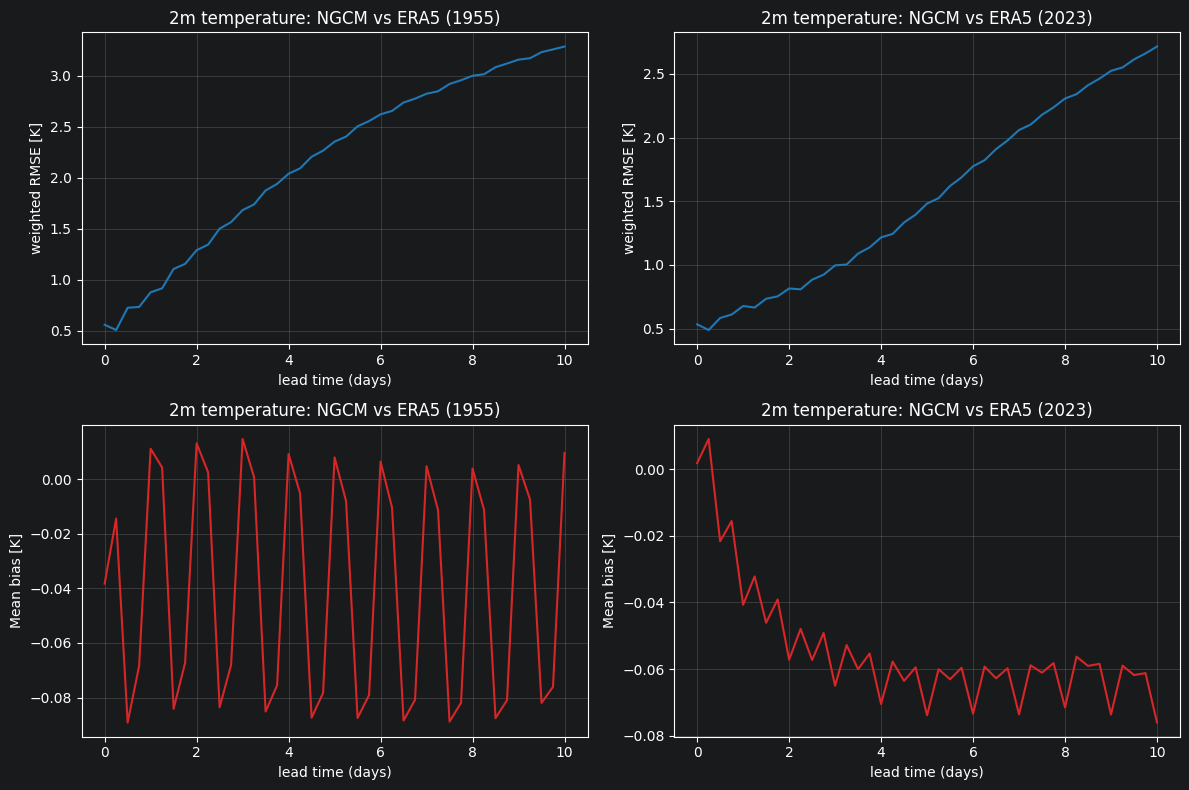

In [12]:
if yearmean:
    n = len(yearmean)

    fig, axes = plt.subplots(2, n, figsize=(6 * n, 8), squeeze=False)

    for col, (year, agg) in enumerate(yearmean.items()):
        # RMSE subplot
        ax_rmse = axes[0, col]
        ax_rmse.plot(agg["lead_day"], agg["t2m_rmse_k"], color="#1f77b4")
        ax_rmse.set_title(f"2m temperature: NGCM vs ERA5 ({year})")
        ax_rmse.set_xlabel("lead time (days)")
        ax_rmse.set_ylabel("weighted RMSE [K]")
        ax_rmse.grid(True, alpha=0.3)

        # Bias subplot
        ax_bias = axes[1, col]
        ax_bias.plot( agg["lead_day"], agg["t2m_mean_bias_k"], color="#d62728")
        ax_bias.set_title(f"2m temperature: NGCM vs ERA5 ({year})")
        ax_bias.set_xlabel("lead time (days)")
        ax_bias.set_ylabel("Mean bias [K]")
        ax_bias.grid(True, alpha=0.3)

    fig.tight_layout()

else:
    print("No results yet.")

## 7. Notes

- **Output:** per-year `results_daily/daily_rollout_<year>.csv` (one row per init x lead - the full
  series of 40 predictions per day) and `daily_rollout_<year>_yearmean.csv` (the Rackow Fig.-1 curve).
  Columns are GraphCast-comparable (`step, lead_hours, lead_day, t2m_rmse_k, t2m_mean_bias_k`, plus the
  predicted/true global-mean series).
- **Full run = HPC/overnight** (~730 rollouts). Run headless and resumable:
  ```bash
  XLA_PYTHON_CLIENT_PREALLOCATE=false XLA_PYTHON_CLIENT_ALLOCATOR=default \
    .venv/bin/python -m nbconvert --to notebook --execute --inplace \
    --ExecutePreprocessor.kernel_name=neuralgcm --ExecutePreprocessor.timeout=-1 \
    rackow_daily_rollouts.ipynb
  ```
  If interrupted, just re-run - finished init days are skipped.
- **Quick test:** `RACKOW_MAX_INITS=2` (and/or `RACKOW_YEARS=2023`).
- **Memory:** keep `XLA_PYTHON_CLIENT_ALLOCATOR=default` (BFC) for the long loop; the `platform`
  allocator can hard-kill the kernel over many forecasts on a 20 GiB card.
- **Years** default to 1955 & 2023 (Rackow climate states); set `RACKOW_YEARS` to change.